In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch

In [2]:
s_and_p = yf.download('^GSPC', start='2020-12-11', end='2026-03-11')

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


In [3]:
s_and_p = s_and_p['Close']

In [4]:
s_and_p['pct_change'] = s_and_p.pct_change()

In [5]:
s_and_p

Ticker,^GSPC,pct_change
Date,,
2020-12-11,3663.459961,NaN
2020-12-14,3647.489990,-0.004359
2020-12-15,3694.620117,0.012921
2020-12-16,3701.169922,0.001773
2020-12-17,3722.479980,0.005758
...,...,...
2026-03-04,6869.500000,0.007756
2026-03-05,6830.709961,-0.005647
2026-03-06,6740.020020,-0.013277


In [6]:
qbts = yf.download('QBTS', start='2020-12-11', end='2026-03-11')

[*********************100%***********************]  1 of 1 completed


In [7]:
qbts = qbts['Close']

In [8]:
qbts['pct_change'] = qbts.pct_change()

In [9]:
qbts

Ticker,QBTS,pct_change
Date,,
2020-12-11,10.150000,NaN
2020-12-14,10.160000,0.000985
2020-12-15,10.110000,-0.004921
2020-12-16,10.140000,0.002967
2020-12-17,10.200000,0.005917
...,...,...
2026-03-04,18.910000,0.036732
2026-03-05,18.830000,-0.004231
2026-03-06,18.590000,-0.012746


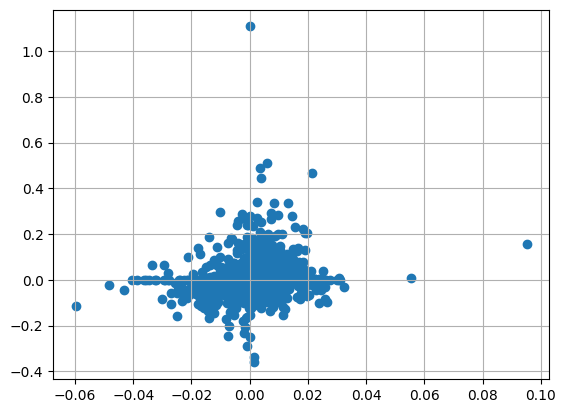

In [10]:
plt.scatter(s_and_p['pct_change'], qbts['pct_change'])
plt.grid(True)
plt.show()

In [11]:
linear_regression = pd.DataFrame({
    'r_qbts': qbts['pct_change'],
    'r_sp': s_and_p['pct_change']
}).dropna()

In [12]:
lr_np = linear_regression.to_numpy()
x = torch.tensor(lr_np[:, 1], dtype=torch.float32).unsqueeze(1)
ones = torch.ones((x.shape[0],1), dtype=torch.float32)
x = torch.cat((ones, x), dim=1)
y = torch.tensor(lr_np[:, 0], dtype=torch.float32)

In [13]:
x

tensor([[ 1.0000, -0.0044],
        [ 1.0000,  0.0129],
        [ 1.0000,  0.0018],
        ...,
        [ 1.0000, -0.0133],
        [ 1.0000,  0.0083],
        [ 1.0000, -0.0021]])

In [14]:
beta = torch.inverse(x.T@x)@x.T@y

In [16]:
plot_x = np.linspace(-0.1,0.1,1000)
plot_y = beta[0] + beta[1]*plot_x

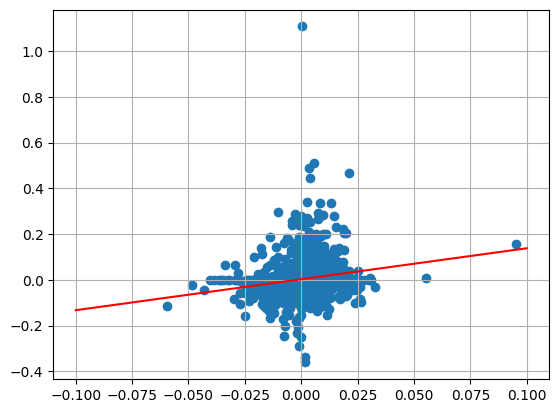

In [17]:
plt.scatter(s_and_p['pct_change'], qbts['pct_change'])
plt.plot(plot_x, plot_y, color='r')
plt.grid(True)
plt.show()

In [18]:
type(beta)

torch.Tensor

In [19]:
def get_alpha_and_beta(stock: str, index: str, start: str,
        end: str, interval: str = '1d', plot: bool = False) -> torch.Tensor:
    
    index = yf.download(index, start=start, end=end, interval=interval)
    index = index['Close']
    index['pct_change'] = index.pct_change()
    stock = yf.download(stock, start=start, end=end, interval=interval)
    stock = stock['Close']
    stock['pct_change'] = stock.pct_change()

    linear_regression = pd.DataFrame({
    'r_s': stock['pct_change'],
    'r_i': index['pct_change']
    }).dropna()

    lr_np = linear_regression.to_numpy()
    x = torch.tensor(lr_np[:, 1], dtype=torch.float32).unsqueeze(1)
    ones = torch.ones((x.shape[0],1), dtype=torch.float32)
    x = torch.cat((ones, x), dim=1)
    y = torch.tensor(lr_np[:, 0], dtype=torch.float32)

    beta_v = torch.inverse(x.T@x)@x.T@y

    alpha, beta = beta_v[0].item(), beta_v[1].item()

    if plot:
        plot_x = np.linspace(index['pct_change'].min(), index['pct_change'].max(), 1000)
        plot_y = alpha + beta*plot_x
        plt.scatter(index['pct_change'], stock['pct_change'])
        plt.plot(plot_x, plot_y, color='r')
        plt.grid(True)
        plt.show()
 
    return alpha, beta

In [20]:
def compute_volatility(asset: pd.DataFrame) -> float:
    """
    Why write a function for this? Because we can
    """
    asset.dropna().to_numpy()
    asset_mean = np.mean(asset)
    var = ((asset - asset_mean)**2).sum() / (asset.shape[0] - 1)

    return float(np.sqrt(var))


In [21]:
compute_volatility(qbts['pct_change'])

0.0799217872659509

In [22]:
qbts['pct_change']

Date
2020-12-11         NaN
2020-12-14    0.000985
2020-12-15   -0.004921
2020-12-16    0.002967
2020-12-17    0.005917
                ...   
2026-03-04    0.036732
2026-03-05   -0.004231
2026-03-06   -0.012746
2026-03-09    0.024207
2026-03-10   -0.014706
Name: pct_change, Length: 1315, dtype: float64